In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings

In [2]:
salary = pd.read_excel('Salary_data.xlsx')

In [3]:
salary.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [5]:
#First check for null values. We see that there are 2 null vaues for esch columns. It's no longer showing the null values
#because the data has been cleaned and i reran this particular cell after cleaning the data set 
salary.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [6]:
salary.duplicated().sum()

np.int64(50)

In [7]:
#We use the command to preview where the null values are
salary[salary.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#We use dropna because the entire row is empty
salary.dropna(inplace=True)

In [9]:
salary.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [10]:
salary[salary.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary


In [11]:
#To change the datatype of Age from float to integer,
salary['Age']=salary['Age'].astype(int)

In [12]:
#To change the datatype of Years from experience from float to integer,
salary['Years of Experience']=salary['Years of Experience'].astype(int)

In [13]:
salary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    int64  
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    int64  
 5   Salary               373 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 20.4+ KB


In [14]:
salary.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.013405,100577.345845
std,7.069073,6.580546,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [15]:
#To select the numeric variables in a dataset
salary.select_dtypes(include=['int','float'])
#This gives us only the columns where we have just numbers

,Age,Years of Experience,Salary
0,32,5,90000.0
1,28,3,65000.0
2,45,15,150000.0
3,36,7,60000.0
4,52,20,200000.0
...,...,...,...
370,35,8,85000.0
371,43,19,170000.0
372,29,2,40000.0
373,34,7,90000.0


In [16]:
num_column=salary.select_dtypes(include=['int','float'])

In [17]:
num_column.corr()
#In this dataset, there is no negative correlation. This means that as age is increasing, years of experience is increasing
#Same with others
#Note that any variable correlating with itself will be one

,Age,Years of Experience,Salary
Age,1.000000,0.979371,0.922335
Years of Experience,0.979371,1.000000,0.930554
Salary,0.922335,0.930554,1.000000


# Introduction to Machine Learning


In [18]:
# An algorithm is a step by step instructions given to the computer on how to solve a problem.
# Supervised learning is used for predictions
# Unsupervised learning is used for clustering

# To highlight many lines using the # i.e to turn them to comments, 
# when you highlight them all, hold your ctrl key and forward slash /

In [19]:
salary

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,Male,Bachelor's,Software Engineer,5,90000.0
1,28,Female,Master's,Data Analyst,3,65000.0
2,45,Male,PhD,Senior Manager,15,150000.0
3,36,Female,Bachelor's,Sales Associate,7,60000.0
4,52,Male,Master's,Director,20,200000.0
...,...,...,...,...,...,...
370,35,Female,Bachelor's,Senior Marketing Analyst,8,85000.0
371,43,Male,Master's,Director of Operations,19,170000.0
372,29,Female,Bachelor's,Junior Project Manager,2,40000.0
373,34,Male,Bachelor's,Senior Operations Coordinator,7,90000.0


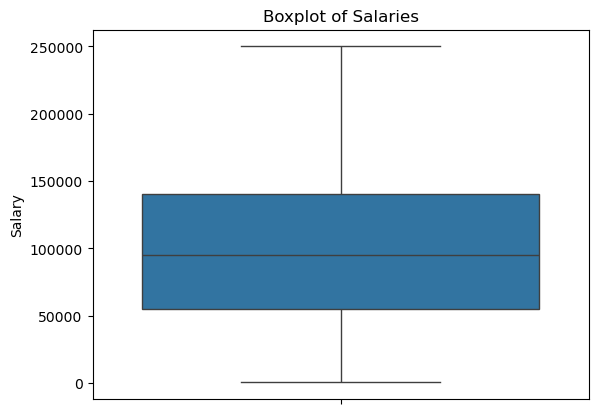

In [20]:
#To create a boxplot to see the distribution of the salary
sb.boxplot(salary['Salary'])
plt.title('Boxplot of Salaries')
plt.show()

In [21]:
# #The above chart means that majority of the salary are above the median (the line inbetween the rectangle 
# reps the median) because the line above the median is longer than the bottom line.

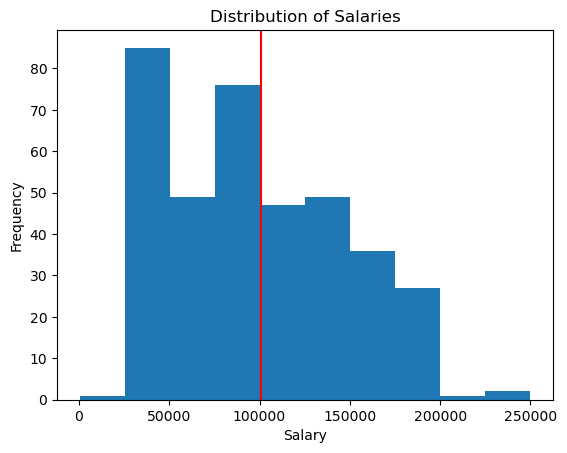

In [106]:
plt.hist(salary['Salary'])
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.title('Distribution of Salaries')
plt.axvline(salary['Salary'].mean(), color='r')
plt.savefig('Salary_plot.png') #To save a chart in a folder created incase you're working on a microsoft file
plt.show()


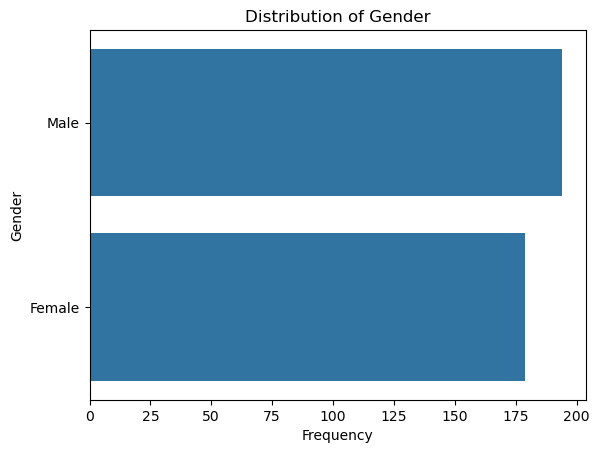

In [23]:
#To know which of the sex - male or female is occurring the most
#i.e. count plot of gender
sb.countplot(salary['Gender'])
plt.xlabel('Frequency')
plt.title('Distribution of Gender')
plt.show()

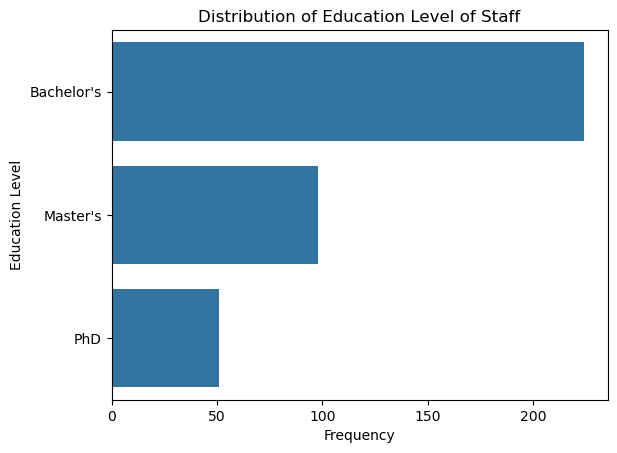

In [24]:
sb.countplot(salary['Education Level'])
plt.title('Distribution of Education Level of Staff')
plt.xlabel('Frequency')
plt.show()

In [25]:
salary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    int64  
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    int64  
 5   Salary               373 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 20.4+ KB


In [26]:
# #Salary is the target label because that is what we're about to predict
# in the above dataset while the other columns are features.

In [27]:
salary['Job Title'].value_counts()

Job Title
Director of Marketing             12
Director of Operations            11
Senior Business Analyst           10
Senior Marketing Manager           9
Senior Marketing Analyst           9
                                  ..
Junior Social Media Specialist     1
Junior Operations Coordinator      1
Senior HR Specialist               1
Director of HR                     1
Junior Financial Advisor           1
Name: count, Length: 174, dtype: int64

In [28]:
# #Data transformation means converting the dataset from categorical variables into numerical variables. 
# To do this, we use the label encoder. Label encorder helps us to convert categorical values to numerical values.

In [29]:
#SInce the above dataset has a mixture of both of them, we need to extract the categorical variables first.
#To do this, first assign it to a variable. The variable name is cat_features
cat_features = salary.select_dtypes(include='object')

In [30]:
cat_features

,Gender,Education Level,Job Title
0,Male,Bachelor's,Software Engineer
1,Female,Master's,Data Analyst
2,Male,PhD,Senior Manager
3,Female,Bachelor's,Sales Associate
4,Male,Master's,Director
...,...,...,...
370,Female,Bachelor's,Senior Marketing Analyst
371,Male,Master's,Director of Operations
372,Female,Bachelor's,Junior Project Manager
373,Male,Bachelor's,Senior Operations Coordinator


In [31]:
#To import label encoder from a module called sklearn.preprocessing 
from sklearn.preprocessing import LabelEncoder

In [32]:
le = LabelEncoder() #then give it an alias 'le'
#le is the variable name given to the alias LabelEncoder

In [33]:
#This replaces the unique variables in gender with numbers in alphabetical order starting with 0
salary['Gender'] = le.fit_transform(salary['Gender'])

In [34]:
salary

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,1,Bachelor's,Software Engineer,5,90000.0
1,28,0,Master's,Data Analyst,3,65000.0
2,45,1,PhD,Senior Manager,15,150000.0
3,36,0,Bachelor's,Sales Associate,7,60000.0
4,52,1,Master's,Director,20,200000.0
...,...,...,...,...,...,...
370,35,0,Bachelor's,Senior Marketing Analyst,8,85000.0
371,43,1,Master's,Director of Operations,19,170000.0
372,29,0,Bachelor's,Junior Project Manager,2,40000.0
373,34,1,Bachelor's,Senior Operations Coordinator,7,90000.0


In [35]:
salary['Education Level'] = le.fit_transform(salary['Education Level'])

In [36]:
salary

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,1,0,Software Engineer,5,90000.0
1,28,0,1,Data Analyst,3,65000.0
2,45,1,2,Senior Manager,15,150000.0
3,36,0,0,Sales Associate,7,60000.0
4,52,1,1,Director,20,200000.0
...,...,...,...,...,...,...
370,35,0,0,Senior Marketing Analyst,8,85000.0
371,43,1,1,Director of Operations,19,170000.0
372,29,0,0,Junior Project Manager,2,40000.0
373,34,1,0,Senior Operations Coordinator,7,90000.0


In [37]:
salary['Job Title'] = le.fit_transform(salary['Job Title'])

In [38]:
salary

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,1,0,159,5,90000.0
1,28,0,1,17,3,65000.0
2,45,1,2,130,15,150000.0
3,36,0,0,101,7,60000.0
4,52,1,1,22,20,200000.0
...,...,...,...,...,...,...
370,35,0,0,131,8,85000.0
371,43,1,1,30,19,170000.0
372,29,0,0,70,2,40000.0
373,34,1,0,137,7,90000.0


In [39]:
#If you have many categorical values that we have to convert to numerical values, 
#we have to use a loop to save time
cat_features.columns #This will bring it as a list

Index(['Gender', 'Education Level', 'Job Title'], dtype='object')

In [40]:
# for i in cat_features.columns:
#     salary[i] = le.fit_transform(salary[i]) 
# We didn't run this because we have already done it above

In [100]:
#To check the correlation for the datset now that everything is now numerical
salary.corr()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
Age,1.000000,-0.020324,0.562693,0.117629,0.979371,0.922335
Gender,-0.020324,1.000000,-0.044717,0.014307,0.003592,0.071106
Education Level,0.562693,-0.044717,1.000000,0.099934,0.589588,0.670371
Job Title,0.117629,0.014307,0.099934,1.000000,0.101549,0.136206
Years of Experience,0.979371,0.003592,0.589588,0.101549,1.000000,0.930554
Salary,0.922335,0.071106,0.670371,0.136206,0.930554,1.000000


In [101]:
sal = salary.corr()

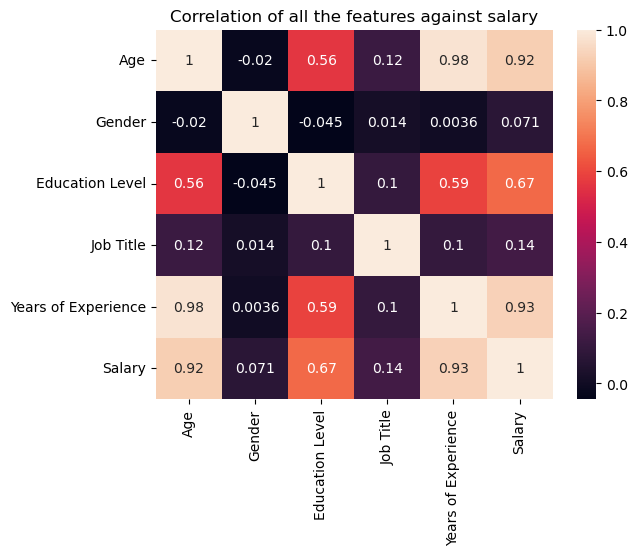

In [102]:
sb.heatmap(sal, annot = True)
plt.title("Correlation of all the features against salary")
plt.show()

## There are two types of regression
- Simple linear Regression - using one variable to predict.
- Multi Linear - using more than one variables to predict.

## Saturday 15th 2025 (contd. of last week's class)

### Simple Linear Regression

In [42]:
#First thing to do is to select features i.e Features Selection that we'll use to train the algorithm.
#We create variable x and y
#x will rep the features(feature is the factor that is influencing the tartget/label we're trying to predict.
#y will rep the label(salary)

In [43]:
x = salary[['Years of Experience']] #Feature
y = salary['Salary']

In [44]:
type(y)

pandas.core.series.Series

In [45]:
type(x)

pandas.core.frame.DataFrame

In [46]:
# #When you have a dataset that you want to create an algorithm, you need to divide your dataset where
# a huge part of it has to be divided to train the algorithm while the smaller part is to test the dataset.
# then we need to import the library - train_test_split, we will use for the machine learning.
from sklearn.model_selection import train_test_split

In [47]:
a, b, c = 2,4,5

In [48]:
a

2

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0) #the test has to be in decimal which means
#20% will go for test while by default, 80% will go for training

In [50]:
x_train

,Years of Experience
342,3
122,5
213,8
63,21
135,10
...,...
325,9
193,7
117,20
47,16


In [51]:
y_train

342     50000.0
122     50000.0
213     85000.0
63     180000.0
135     55000.0
         ...   
325    100000.0
193     95000.0
117    170000.0
47     180000.0
173    140000.0
Name: Salary, Length: 298, dtype: float64

In [52]:
x_test

,Years of Experience
45,2
274,2
54,3
237,16
254,8
...,...
56,2
8,1
199,9
310,1


### Model Building

In [53]:
#Import Linear Regression Algorithm from sklearn (scikit-learn)
from sklearn.linear_model import LinearRegression

In [54]:
#Then input the dataset into the algorithm.
#First call out the imported algorithm and add .fit(x_train,y_train) then assign it to a variable name 'model'
model = LinearRegression().fit(x_train,y_train)

In [55]:
#This is to retrieve the coefficients of the linear model
model.coef_

array([6860.10270698])

In [56]:
#This is to retrieve the intercept of the linear model
model.intercept_

np.float64(31728.78067449534)

In [57]:
model.predict([[9]])

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([93469.70503733])

# Model Accuracy
- This is the point where you test the accuracy of the model you're running
### Model Accuracy metrics for regression: Asolute error is the difference between the predicted value and the actual value
- Mean Absolute Error(MAE) - It's the mean of the absolute error. it changes the negative error to positive
- Mean Squared Error (MSE) - square of the difference btw the actual value and the predicted value before finding the average
- Root Mean Square Error (RMSE) - square root of the MSE
- R2 Score - overall accuracy of the model

In [58]:
#Importing the metrics for regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [59]:
x_test

,Years of Experience
45,2
274,2
54,3
237,16
254,8
...,...
56,2
8,1
199,9
310,1


In [60]:
y_test

45      40000.0
274     40000.0
54      50000.0
237    140000.0
254     85000.0
         ...   
56      65000.0
8       45000.0
199    110000.0
310     35000.0
78     180000.0
Name: Salary, Length: 75, dtype: float64

In [61]:
model.predict(x_test)

array([ 45448.98608846,  45448.98608846,  52309.08879544, 141490.4239862 ,
        86609.60233035, 141490.4239862 ,  59169.19150242, 127770.21857224,
        45448.98608846, 175790.93752111,  66029.2942094 , 114050.01315827,
       134630.32127922,  79749.49962337, 107189.91045129,  59169.19150242,
        52309.08879544,  45448.98608846, 141490.4239862 , 168930.83481412,
        86609.60233035,  86609.60233035, 100329.80774431,  45448.98608846,
       189511.14293507,  45448.98608846,  66029.2942094 ,  66029.2942094 ,
       114050.01315827,  52309.08879544,  66029.2942094 , 114050.01315827,
       114050.01315827, 134630.32127922,  52309.08879544, 114050.01315827,
        52309.08879544, 107189.91045129, 100329.80774431, 114050.01315827,
       127770.21857224, 162070.73210714, 141490.4239862 , 168930.83481412,
       162070.73210714,  45448.98608846,  72889.39691638, 155210.62940016,
        59169.19150242,  86609.60233035,  93469.70503733,  93469.70503733,
        79749.49962337,  

In [62]:
predictions = model.predict(x_test)

In [63]:
#To check for error, we use the mean aboslute error
mae = mean_absolute_error(y_test, predictions)
print(mae)

11197.40518379877


In [64]:
#To check the mean squared error
mse = mean_squared_error(y_test, predictions)
print(mse)

213054476.88430813


In [65]:
#To check the root mean squared error, we use a formula in numpy i.e np.sqrt
rmse = np.sqrt(mse)
print(rmse)

14596.385747311151


In [66]:
r2 = r2_score(y_test,predictions)
print(r2) #This means that we have 89.5% overall accuracy

0.8951673235325662


## Multi Linear Regression

In [67]:
#The variables we're using here is Years of Experience and Age
x = salary[['Years of Experience', 'Age']] #Feature
y = salary['Salary']

In [68]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0) #the test has to be in decimal which means
#20% will go for test while by default, 80% will go for training

In [69]:
x_train

,Years of Experience,Age
342,3,31
122,5,33
213,8,35
63,21,47
135,10,39
...,...,...
325,9,36
193,7,34
117,20,48
47,16,45


In [70]:
model_2 = LinearRegression().fit(x_train,y_train)

In [71]:
#This is to retrieve the coefficients of the linear model
model_2.coef_

array([4900.3485968 , 1880.85670436])

In [72]:
#This is to retrieve the intercept of the linear model
model_2.intercept_

np.float64(-19041.84014062662)

In [73]:
model_2.predict([[9,45]])

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([109699.84892693])

In [74]:
model_2.predict(x_test)

array([ 43422.84477516,  47184.55818389,  50204.05007632, 144002.28910452,
        85990.93328649, 142121.43240015,  60746.96878621, 128559.02179783,
        43422.84477516, 179789.17231469,  67528.17408737, 114996.61119551,
       137221.08380336,  81090.5846897 , 102572.83578125,  62627.82549057,
        52084.90678068,  43422.84477516, 138359.71899143, 173007.96701353,
        84110.07658213,  87871.78999086, 103315.05729755,  45303.70147952,
       189589.86950829,  47184.55818389,  63766.46067864,  67528.17408737,
       118758.32460423,  48323.19337196,  69409.03079174, 114996.61119551,
       114996.61119551, 135340.22709899,  52084.90678068, 114996.61119551,
        50204.05007632, 104453.69248562, 101434.20059318, 114996.61119551,
       128559.02179783, 166226.76171237, 142121.43240015, 169246.2536048 ,
       162465.04830364,  45303.70147952,  68666.80927544, 150041.27288939,
        58866.11208185,  84110.07658213,  96533.85199638,  90891.28188329,
        77328.87128097,  

In [75]:
prediction_2 = model_2.predict(x_test)

In [76]:
#To check for error, we use the mean aboslute error
mae = mean_absolute_error(y_test, prediction_2)
print(mae)

11076.169526187814


In [77]:
#To check the mean squared error
mse = mean_squared_error(y_test, prediction_2)
print(mse)

209763669.0927626


In [78]:
#To check the root mean squared error, we use a formula in numpy i.e np.sqrt
rmse = np.sqrt(mse)
print(rmse)

14483.220259761383


In [79]:
r2 = r2_score(y_test,prediction_2)
print(r2) #This means that we have 89.7% overall accuracy

0.8967865534758775


### Note: If you add a feature taht doesn't have a strong correllation with the label, the accuracy will decrease. So 
it is best to always check the corrrelation before you train your model using the right feature. 

# Sunday 16th November 2025

## Polynomial Regression

#### For simple Linear Regression, the line of best fit is straight while for polynomial regression, the line of best fit is curved.

In [80]:
#First thing to do is to import the library that will help us convert our features into polynomial features
from sklearn.preprocessing import PolynomialFeatures

In [81]:
#Then assign an alias to the library imported. Then assign it to a degree of 2.
poly = PolynomialFeatures(degree=2)

In [82]:
x

,Years of Experience,Age
0,5,32
1,3,28
2,15,45
3,7,36
4,20,52
...,...,...
370,8,35
371,19,43
372,2,29
373,7,34


In [83]:
#Then convert x to a polynomial
x_poly = poly.fit_transform(x)

In [84]:
x_poly

array([[1.000e+00, 5.000e+00, 3.200e+01, 2.500e+01, 1.600e+02, 1.024e+03],
       [1.000e+00, 3.000e+00, 2.800e+01, 9.000e+00, 8.400e+01, 7.840e+02],
       [1.000e+00, 1.500e+01, 4.500e+01, 2.250e+02, 6.750e+02, 2.025e+03],
       ...,
       [1.000e+00, 2.000e+00, 2.900e+01, 4.000e+00, 5.800e+01, 8.410e+02],
       [1.000e+00, 7.000e+00, 3.400e+01, 4.900e+01, 2.380e+02, 1.156e+03],
       [1.000e+00, 1.500e+01, 4.400e+01, 2.250e+02, 6.600e+02, 1.936e+03]])

In [85]:
#We then split it and specify that it's a polynomial
x_train_poly, x_test_poly, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

In [86]:
#To fit into a linear regression model
model_poly = LinearRegression().fit(x_train_poly, y_train)

#### Note that you don't convert the target variable to a polynomial - it's just the features. That's why we didn't convert y. We only converted the x

In [87]:
#Model Accuracy
y_predictions = model_poly.predict(x_test_poly)

In [88]:
mae = mean_absolute_error(y_test, y_predictions)
print(mae)

10630.966120225901


In [89]:
mse = mean_squared_error(y_test, y_predictions)
print(mse)

202449502.65073523


In [90]:
rmse = np.sqrt(mse)
rmse

np.float64(14228.475064135833)

In [91]:
r2 = r2_score(y_test, y_predictions)
r2 #The overall accuracy here is 90%

0.900385462334584

## Decision Tree Regressor

In [92]:
## This is also an algorithm to solve regreesion problem
#First import the library
from sklearn.tree import DecisionTreeRegressor

In [93]:
dt_model = DecisionTreeRegressor().fit(x_train, y_train)

In [94]:
predictions_dt = dt_model.predict(x_test)

In [95]:
mae = mean_absolute_error(y_test, predictions_dt)
print(mae)

12409.807407407407


In [96]:
mse = mean_squared_error(y_test, predictions_dt)
print(mse)

297752408.95473254


In [97]:
rmse = np.sqrt(mse)
rmse

np.float64(17255.503729382475)

In [98]:
r2 = r2_score(y_test, predictions_dt)
r2 #The overall accuracy is 85.3%

0.85349201569559

#### From the above, if we're to decide on what we should use, we can either use linear regression or polynomial regression instead of the decision tree regressor because the later is lower than the other former two